In [1]:
from skimage import io, feature, color
import numpy as np
from matplotlib import pyplot as plt

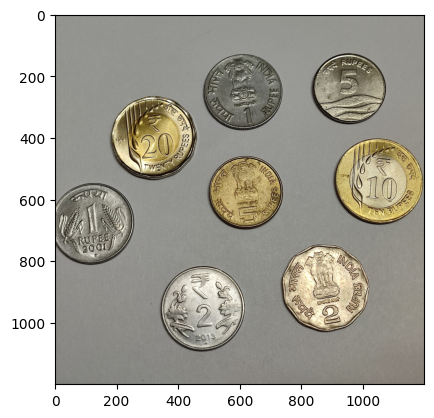

In [2]:
image = io.imread("coin.jpg")

image_gray = color.rgb2gray(image)
plt.imshow(image, "gray")

In [3]:
foreground = [(300, 400), (500, 1000), (1000, 500), (700, 600)]
background = [(200, 200), (700, 1000), (600, 800), (800, 400)]

In [4]:
square_size = 50
foreground_color = (0, 0, 255)
background_color = (255, 0, 0)
line_width = 8

In [5]:
marked_image = image.copy()

In [6]:
# Mark the ROIs

for x, y in foreground:
    top_left = (max(0, x - square_size // 2), max(0, y - square_size // 2))
    bottom_right = (
        min(image.shape[1], x + square_size // 2),
        min(image.shape[0], y + square_size // 2),
    )

    # Draw top and bottom lines
    marked_image[
        top_left[1] : top_left[1] + line_width, top_left[0] : bottom_right[0]
    ] = foreground_color
    marked_image[
        bottom_right[1] - line_width : bottom_right[1], top_left[0] : bottom_right[0]
    ] = foreground_color

    # Draw left and right lines
    marked_image[
        top_left[1] : bottom_right[1], top_left[0] : top_left[0] + line_width
    ] = foreground_color
    marked_image[
        top_left[1] : bottom_right[1], bottom_right[0] - line_width : bottom_right[0]
    ] = foreground_color

for x, y in background:
    top_left = (max(0, x - square_size // 2), max(0, y - square_size // 2))
    bottom_right = (
        min(image.shape[1], x + square_size // 2),
        min(image.shape[0], y + square_size // 2),
    )

    marked_image[
        top_left[1] : top_left[1] + line_width, top_left[0] : bottom_right[0]
    ] = background_color
    marked_image[
        bottom_right[1] - line_width : bottom_right[1], top_left[0] : bottom_right[0]
    ] = background_color
    marked_image[
        top_left[1] : bottom_right[1], top_left[0] : top_left[0] + line_width
    ] = background_color
    marked_image[
        top_left[1] : bottom_right[1], bottom_right[0] - line_width : bottom_right[0]
    ] = background_color

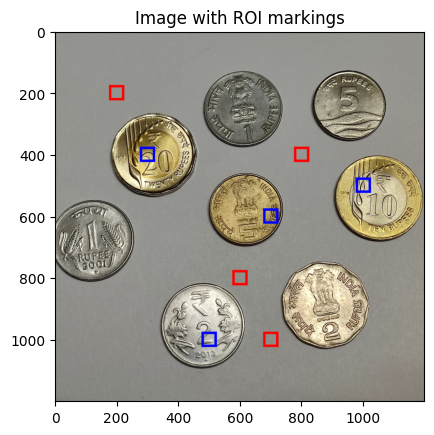

In [7]:
plt.imshow(marked_image)
plt.title("Image with ROI markings")
plt.show()

In [8]:
distances = [1]
angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]

In [9]:
def get_glcm_stats(roi):
    x_min, y_min = min(x for x, _ in roi), min(y for _, y in roi)
    x_max, y_max = max(x for x, _ in roi), max(y for _, y in roi)
    roi_image = (image_gray[y_min : y_max + 1, x_min : x_max + 1] * 255).astype(np.uint8)

    glcm = feature.graycomatrix(roi_image, distances=distances, angles=angles)

    roi_min = roi_image.min()
    roi_max = roi_image.max()
    roi_mean = roi_image.mean()

    return glcm, roi_min, roi_max, roi_mean

In [10]:
foreground_glcm, foreground_min, foreground_max, foreground_mean = get_glcm_stats(
    foreground
)
background_glcm, background_min, background_max, background_mean = get_glcm_stats(
    background
)

In [11]:
# Display min and max values
print("Foreground ROI min:", foreground_min)
print("Foreground ROI max:", foreground_max)
print("Background ROI min:", background_min)
print("Background ROI max:", background_max)
print("Foreground ROI mean:", foreground_mean)
print("Background ROI mean:", background_mean)

Foreground ROI min: 0
Foreground ROI max: 254
Background ROI min: 0
Background ROI max: 255
Foreground ROI mean: 150.96129133327477
Background ROI mean: 142.11016387585403


In [13]:
# Compute properties from GLCM
contrast_foreground = feature.graycoprops(foreground_glcm, 'contrast')[0, 0]
correlation_foreground = feature.graycoprops(foreground_glcm, 'correlation')[0, 0]

contrast_background = feature.graycoprops(background_glcm, 'contrast')[0, 0]
correlation_background = feature.graycoprops(background_glcm, 'correlation')[0, 0]

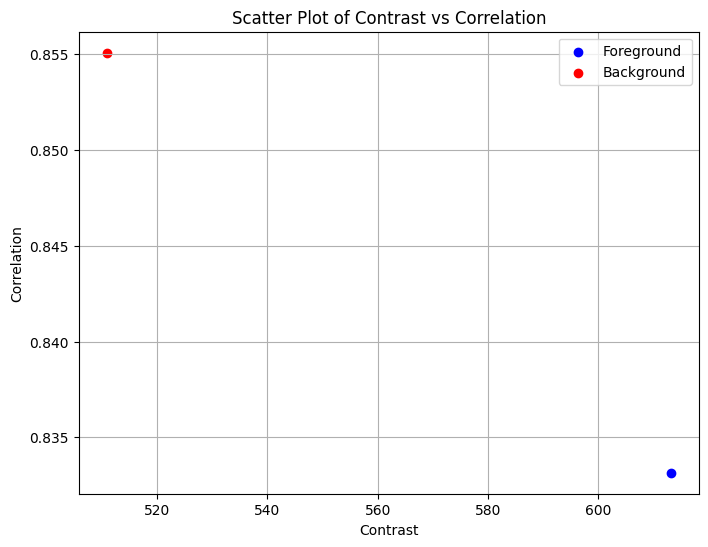

In [14]:
# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(contrast_foreground, correlation_foreground, color='b', label='Foreground')
plt.scatter(contrast_background, correlation_background, color='r', label='Background')
plt.xlabel('Contrast')
plt.ylabel('Correlation')
plt.title('Scatter Plot of Contrast vs Correlation')
plt.legend()
plt.grid(True)
plt.show()